# Team Members
##Nadil Karunarathna-24618
##Anjali Senadhira-25411
##Basilu de Silva-25331


# Import libraries


## Install required libraries

In [ ]:
!pip install wbgapi pandas

## Import the relevant libraries
#### Please allow access to mount the google drive

In [ ]:
import wbgapi as wb
import pandas as pd
import os
from google.colab import drive #save this file to drive
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from pyspark.ml.feature import RobustScaler, VectorAssembler, PCA
from pyspark.sql.functions import monotonically_increasing_id
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier
from pyspark.sql.window import Window
from pyspark.ml.feature import StringIndexer
from sklearn.metrics import confusion_matrix
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from sklearn.linear_model import LinearRegression
from pyspark.ml.feature import VectorAssembler
from pyspark.sql import functions as F
from pyspark.sql.types import (DoubleType,IntegerType,StringType,StructField,StructType,)
from statsmodels.tsa.api import SimpleExpSmoothing, Holt
from sklearn.metrics import mean_squared_error, r2_score
drive.mount('/content/drive') #mount my google drive

Mounted at /content/drive


# Retrieve the data and save it in drive

In [ ]:
# Step 2: Define paths
folder_path = '/content/drive/MyDrive/Assignment Big Datasets'
os.makedirs(folder_path, exist_ok=True)
file_path = os.path.join(folder_path, 'world_bank_cmri_dataset.csv')

# Step 3: Check if file already exists
if os.path.exists(file_path):
    print(f"File already exists at: {file_path}. Skipping download.")
else:
    print("File not found. Downloading dataset from World Bank API... This may take a few minutes")

    # Step 4: Define World Bank indicator mapping
    indicators = {
        'NY.GDP.MKTP.KD.ZG': 'gdp_growth',
        'FP.CPI.TOTL.ZG': 'inflation',
        'SL.UEM.TOTL.ZS': 'unemployment',
        'GC.DOD.TOTL.GD.ZS': 'govt_debt',
        'BN.CAB.XOKA.GD.ZS': 'current_account_bal',
        'FS.AST.PRVT.GD.ZS': 'domestic_credit',
        'PA.NUS.FCRF': 'exchange_rate',
        'FM.LBL.BMNY.ZG': 'money_growth'
    }

    # Step 5: Extract multi-country multi-decade panel dataset (1990–2024)
    df = wb.data.DataFrame(
        series=list(indicators.keys()),
        time=range(1990, 2025),
        skipAggs=True,
        labels=True
    ).reset_index()

    # Step 6: Save directly to Google Drive
    df.to_csv(file_path, index=False)
    print(f"Dataset successfully downloaded and saved to: {file_path}")

File already exists at: /content/drive/MyDrive/Assignment Big Datasets/world_bank_cmri_dataset.csv. Skipping download.


# Now properly format the dataset

In [ ]:
# 2. Initialize Spark Session
spark = SparkSession.builder \
    .appName("WorldBankDataReshaping") \
    .getOrCreate()

# 3. Load raw dataset from Google Drive
output_folder = '/content/drive/MyDrive/Assignment Big Datasets'
raw_csv_path = os.path.join(output_folder, 'world_bank_cmri_dataset.csv')
df_raw = spark.read.csv(raw_csv_path, header=True, inferSchema=True)

# Metadata columns
id_cols = ['economy', 'Country', 'series1', 'Series3']

# Identify year columns dynamically
year_cols = [c for c in df_raw.columns if c not in id_cols]

# 4. UNPIVOT (MELT): Convert Year columns into a single 'Year' column
df_long = df_raw.melt(
    ids=id_cols,
    values=year_cols,
    variableColumnName="Year",
    valueColumnName="Value"
)

# Clean up Year and Value columns
df_long = df_long.withColumn("Year", F.regexp_replace(F.col("Year"), r"[^\d]", "").cast("int"))
df_long = df_long.withColumn("Value", F.col("Value").cast("double"))

# 5. MAP SERIES CODES TO CLEAN INDICATOR NAMES
indicator_mapping = F.create_map([
    F.lit('NY.GDP.MKTP.KD.ZG'), F.lit('gdp_growth'),
    F.lit('FP.CPI.TOTL.ZG'), F.lit('inflation'),
    F.lit('SL.UEM.TOTL.ZS'), F.lit('unemployment'),
    F.lit('GC.DOD.TOTL.GD.ZS'), F.lit('govt_debt'),
    F.lit('BN.CAB.XOKA.GD.ZS'), F.lit('current_account_bal'),
    F.lit('FS.AST.PRVT.GD.ZS'), F.lit('domestic_credit'),
    F.lit('PA.NUS.FCRF'), F.lit('exchange_rate'),
    F.lit('FM.LBL.BMNY.ZG'), F.lit('money_growth')
])

df_long = df_long.withColumn("Indicator_Name", indicator_mapping[F.col("series1")])

# 6. PIVOT: Create single row per Country-Year with indicators as columns
df_final = df_long.groupBy("economy", "Country", "Year") \
    .pivot("Indicator_Name") \
    .agg(F.first("Value")) \
    .sort("Country", "Year")

# View the transformed DataFrame structure
print("--- Reshaped Panel Data Structure ---")
df_final.printSchema()
df_final.show(10, truncate=False)

# 7. Save and overwrite existing file
output_file = os.path.join(output_folder, 'reshaped_world_bank_panel.csv')

# Always overwrites the file if it exists
df_final.toPandas().to_csv(output_file, index=False)
print(f"\nReshaped dataset successfully updated and saved to: {output_file}")

--- Reshaped Panel Data Structure ---
root
 |-- economy: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- current_account_bal: double (nullable = true)
 |-- domestic_credit: double (nullable = true)
 |-- exchange_rate: double (nullable = true)
 |-- gdp_growth: double (nullable = true)
 |-- govt_debt: double (nullable = true)
 |-- inflation: double (nullable = true)
 |-- money_growth: double (nullable = true)
 |-- unemployment: double (nullable = true)

+-------+-----------+----+-------------------+---------------+----------------+----------+---------+---------+----------------+------------+
|economy|Country    |Year|current_account_bal|domestic_credit|exchange_rate   |gdp_growth|govt_debt|inflation|money_growth    |unemployment|
+-------+-----------+----+-------------------+---------------+----------------+----------+---------+---------+----------------+------------+
|AFG    |Afghanistan|1990|NULL               |NULL           |3

#Data source - World Bank Open Data

# Number of records = 7595 records

In [ ]:
print(f"Number of records: {df_final.count()}")

Number of records: 7595


# Number of attributes = 11

In [ ]:
print(f"Number of attributes in df_final: {len(df_final.columns)}")

Number of attributes in df_final: 11


#Data Types

In [ ]:
print("Data Types of Attributes in df_final:")
for col_name, data_type in df_final.dtypes:
    print(f"{col_name}: {data_type}")

Data Types of Attributes in df_final:
economy: string
Country: string
Year: int
current_account_bal: double
domestic_credit: double
exchange_rate: double
gdp_growth: double
govt_debt: double
inflation: double
money_growth: double
unemployment: double


# Outliers before removing variables


================== 1.5 * IQR OUTLIER SUMMARY TABLE ==================
          Attribute  Q1 (25%)  Q3 (75%)      IQR  Lower Bound  Upper Bound  Outlier Count Outlier (%)
         gdp_growth    1.1095    5.8557   4.7462      -6.0097      12.9749            563       7.92%
          inflation    1.8148    8.4308   6.6160      -8.1093      18.3549            593       9.86%
       unemployment    3.6560   11.0000   7.3440      -7.3600      22.0160            226       3.56%
          govt_debt   29.8020   69.0998  39.2978     -29.1448     128.0465             63       3.83%
current_account_bal   -6.9968    1.5737   8.5706     -19.8527      14.4296            511       8.79%
    domestic_credit   15.1475   61.8368  46.6892     -54.8863     131.8706            295       5.74%
      exchange_rate    1.2496  103.3847 102.1351    -151.9531     256.5874           1356      19.04%
       money_growth    6.0105   20.3844  14.3739     -15.5503      41.9453            402       7.69%


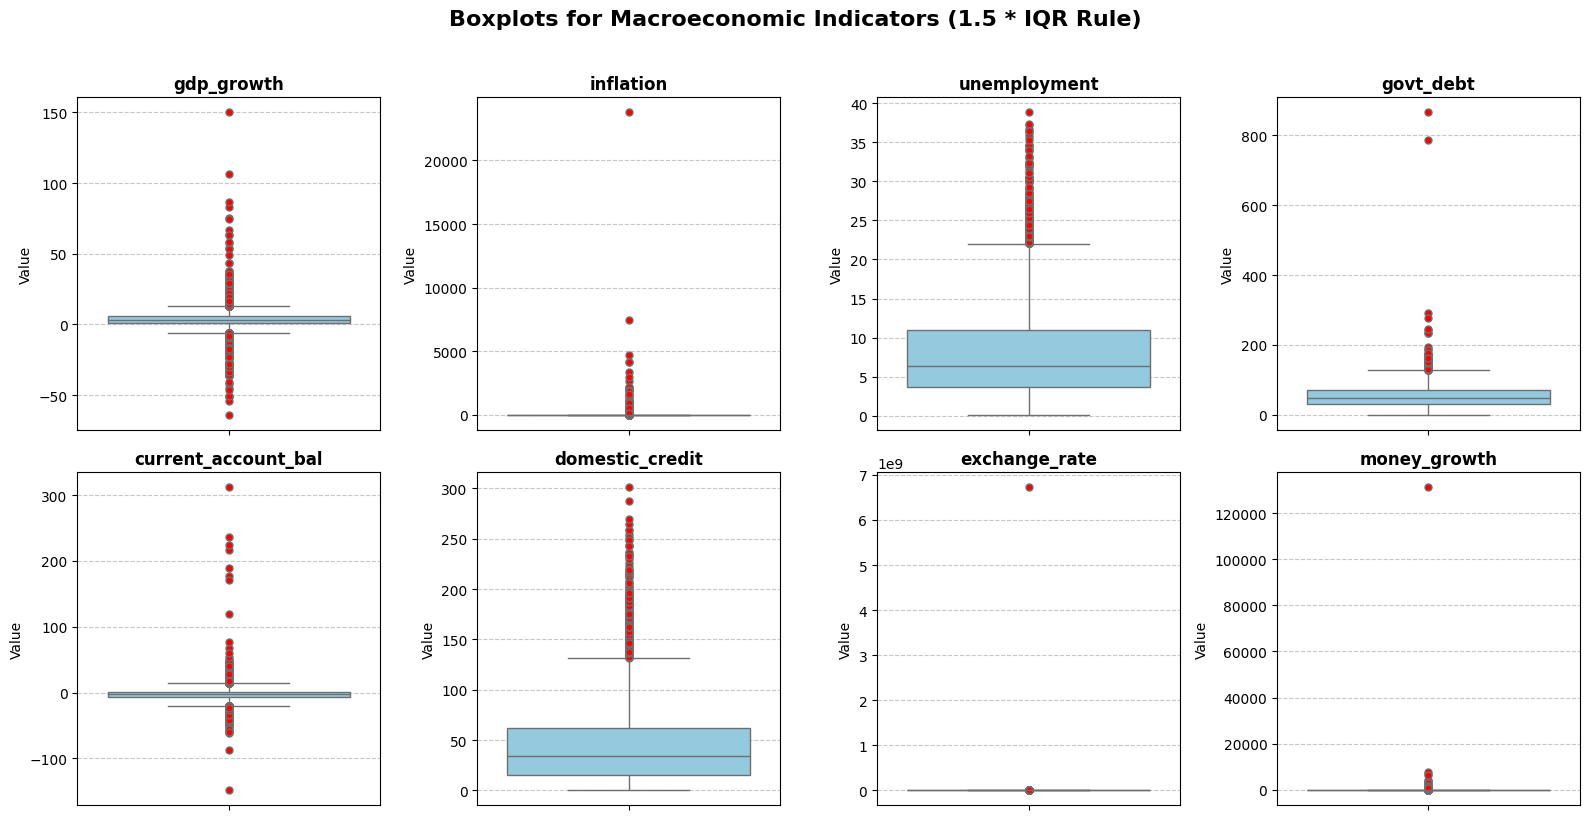

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Assign df_final to a new DataFrame
df_outlier_analysis = df_final

# 2. List of numerical indicators to analyze for outliers
num_cols = [
    'gdp_growth', 'inflation', 'unemployment',
    'govt_debt', 'current_account_bal', 'domestic_credit',
    'exchange_rate', 'money_growth'
]

# Filter list to ensure only existing columns in df_outlier_analysis are used
existing_num_cols = [c for c in num_cols if c in df_outlier_analysis.columns]

# 3. Convert PySpark numerical subset to Pandas for statistical processing and plotting
pdf = df_outlier_analysis.select(existing_num_cols).toPandas()

# 4. Calculate 1.5 * IQR Outliers and create summary table
summary_list = []

for col in existing_num_cols:
    series = pdf[col].dropna()  # Exclude nulls for IQR calculation

    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = series[(series < lower_bound) | (series > upper_bound)]
    outlier_count = len(outliers)
    outlier_pct = (outlier_count / len(series)) * 100 if len(series) > 0 else 0

    summary_list.append({
        'Attribute': col,
        'Q1 (25%)': round(Q1, 4),
        'Q3 (75%)': round(Q3, 4),
        'IQR': round(IQR, 4),
        'Lower Bound': round(lower_bound, 4),
        'Upper Bound': round(upper_bound, 4),
        'Outlier Count': outlier_count,
        'Outlier (%)': f"{outlier_pct:.2f}%"
    })

# Convert summary list to a Pandas DataFrame and display as a table
df_summary = pd.DataFrame(summary_list)
print("\n================== 1.5 * IQR OUTLIER SUMMARY TABLE ==================")
print(df_summary.to_string(index=False))

# 5. Plot Boxplots for all numerical attributes
n_cols = len(existing_num_cols)
rows = (n_cols + 3) // 4  # 4 plots per row grid calculation

plt.figure(figsize=(16, 4 * rows))
plt.suptitle("Boxplots for Macroeconomic Indicators (1.5 * IQR Rule)", fontsize=16, fontweight='bold', y=1.02)

for i, col in enumerate(existing_num_cols, 1):
    plt.subplot(rows, 4, i)
    sns.boxplot(y=pdf[col], color='skyblue', flierprops=dict(marker='o', markerfacecolor='red', markersize=5))
    plt.title(col, fontsize=12, fontweight='bold')
    plt.ylabel("Value")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#Target Variable

For this we need to make a target variable called CMRI - Composite Macroeconomic risk indicator

That indicator is constructed and determined based on the other variables in the model. Then the CRMI of countries make them categorized into High Risk Moderate Risk and Low risk

# Data Preprocessing

# 1. Remove Duplicates

In [ ]:
# 1. Check total initial count
initial_count = df_final.count()
print(f"Initial Row Count: {initial_count}")

# 2. Step 4.1: Remove Exact Duplicate Records
df_dedup = df_final.dropDuplicates()

# 3. Step 4.2: Ensure Primary Key Uniqueness (Country + Year)
# If duplicates exist on Country & Year, keep the first observation
df_dedup = df_dedup.dropDuplicates(subset=["Country", "Year"])

# 4. Verify post-deduplication count
final_count = df_dedup.count()
removed_rows = initial_count - final_count

print(f"Final Row Count after Deduplication: {final_count}")
print(f"Duplicate Records Removed: {removed_rows}")

Initial Row Count: 7595
Final Row Count after Deduplication: 7595
Duplicate Records Removed: 0


# 2. Missing Values

## i. Diagnostic

In [ ]:
# 2. Define File Paths (connected to your Google Drive folder)
output_folder = '/content/drive/MyDrive/Assignment Big Datasets'
file_path = os.path.join(output_folder, 'reshaped_world_bank_panel.csv')

# 3. Read raw reshaped dataset from Google Drive
df_spark = spark.read.csv(file_path, header=True, inferSchema=True)

print("--- INITIAL MISSINGNESS ANALYSIS (%) ---")
total_rows = df_spark.count()
indicators = ['current_account_bal', 'domestic_credit', 'exchange_rate',
              'gdp_growth', 'govt_debt', 'inflation', 'money_growth', 'unemployment']

for col in indicators:
    null_cnt = df_spark.filter(F.col(col).isNull()).count()
    pct = (null_cnt / total_rows) * 100
    print(f"{col}: {null_cnt} missing ({pct:.2f}%)")

--- INITIAL MISSINGNESS ANALYSIS (%) ---
current_account_bal: 1782 missing (23.46%)
domestic_credit: 2453 missing (32.30%)
exchange_rate: 472 missing (6.21%)
gdp_growth: 485 missing (6.39%)
govt_debt: 5950 missing (78.34%)
inflation: 1580 missing (20.80%)
money_growth: 2370 missing (31.20%)
unemployment: 1246 missing (16.41%)


## ii. Remove the gov_debt attribute

In [ ]:
# 1. Drop high-missingness attribute (govt_debt)
df_clean = df_spark.drop("govt_debt")
feature_cols = ['current_account_bal', 'domestic_credit', 'exchange_rate',
                'gdp_growth', 'inflation', 'money_growth', 'unemployment']
df_clean.show(5)

+-------+-----------+----+-------------------+---------------+---------------+----------+---------+----------------+------------+
|economy|    Country|Year|current_account_bal|domestic_credit|  exchange_rate|gdp_growth|inflation|    money_growth|unemployment|
+-------+-----------+----+-------------------+---------------+---------------+----------+---------+----------------+------------+
|    AFG|Afghanistan|1990|               NULL|           NULL|39.276429270146|      NULL|     NULL|40.5945754845902|        NULL|
|    AFG|Afghanistan|1991|               NULL|           NULL|39.276429270146|      NULL|     NULL|            NULL|       7.972|
|    AFG|Afghanistan|1992|               NULL|           NULL|39.276429270146|      NULL|     NULL|            NULL|       7.958|
|    AFG|Afghanistan|1993|               NULL|           NULL|39.276429270146|      NULL|     NULL|            NULL|       7.908|
|    AFG|Afghanistan|1994|               NULL|           NULL|      38.818463|      NULL| 

## iii. Identify the null values per row

In [ ]:

# Calculate total nulls per row for feature columns
df_null_calc = df_clean.withColumn(
    "row_null_count",
    sum(F.when(F.col(c).isNull(), 1).otherwise(0) for c in feature_cols)
)
df_null_calc.show(5)

+-------+-----------+----+-------------------+---------------+---------------+----------+---------+----------------+------------+--------------+
|economy|    Country|Year|current_account_bal|domestic_credit|  exchange_rate|gdp_growth|inflation|    money_growth|unemployment|row_null_count|
+-------+-----------+----+-------------------+---------------+---------------+----------+---------+----------------+------------+--------------+
|    AFG|Afghanistan|1990|               NULL|           NULL|39.276429270146|      NULL|     NULL|40.5945754845902|        NULL|             5|
|    AFG|Afghanistan|1991|               NULL|           NULL|39.276429270146|      NULL|     NULL|            NULL|       7.972|             5|
|    AFG|Afghanistan|1992|               NULL|           NULL|39.276429270146|      NULL|     NULL|            NULL|       7.958|             5|
|    AFG|Afghanistan|1993|               NULL|           NULL|39.276429270146|      NULL|     NULL|            NULL|       7.908| 

## iii Calculate the average missing percentage per country

In [ ]:
# Calculate average missingness percentage per country
country_missingness = df_null_calc.groupBy("Country").agg(
    (F.sum("row_null_count") / (F.count("*") * len(feature_cols)) * 100).alias("missing_pct")
)
country_missingness.show(5)


+----------------+-------------------+
|         Country|        missing_pct|
+----------------+-------------------+
|            Chad|  15.10204081632653|
|        Paraguay|0.40816326530612246|
|Congo, Dem. Rep.| 15.510204081632653|
|         Senegal| 0.8163265306122449|
|      Cabo Verde|0.40816326530612246|
+----------------+-------------------+
only showing top 5 rows


In [ ]:
country_missingness.orderBy(F.col("missing_pct").desc()).show(5, truncate=False)

+-------------------------+-----------------+
|Country                  |missing_pct      |
+-------------------------+-----------------+
|British Virgin Islands   |100.0            |
|Korea, Dem. People's Rep.|86.12244897959184|
|Gibraltar                |85.71428571428571|
|St. Martin (French part) |82.85714285714286|
|Andorra                  |81.63265306122449|
+-------------------------+-----------------+
only showing top 5 rows


## iv. Remove countries with more than 20% average missing value rate

In [ ]:
# Filter valid countries (missingness <= 20%)
valid_countries = country_missingness.filter(F.col("missing_pct") <= 20).select("Country")
df_clean = df_clean.join(valid_countries, on="Country", how="inner")

# Dropped countries
df_dropped_countries = country_missingness.filter(F.col("missing_pct") > 20) \
                                           .sort(F.col("missing_pct").desc())

# 7. Save and overwrite existing file
output_file_1 = os.path.join(output_folder, 'dataset_after_countries_removed.csv')
output_file_2 = os.path.join(output_folder, 'countries_removed.csv')


# Always overwrites the file if it exists
df_clean.toPandas().to_csv(output_file_1, index=False)
df_dropped_countries.toPandas().to_csv(output_file_2, index=False)


print(f"Countries remaining after dropping high-missingness entities: {df_clean.select('Country').distinct().count()}")
print(f"Total rows remaining: {df_clean.count()}")

print(f"\nReshaped dataset successfully updated and saved to: {output_file}")
print(f"\nCountries removed and saved to: {output_file_2}")

Countries remaining after dropping high-missingness entities: 155
Total rows remaining: 5425

Reshaped dataset successfully updated and saved to: /content/drive/MyDrive/Assignment Big Datasets/reshaped_world_bank_panel.csv

Countries removed and saved to: /content/drive/MyDrive/Assignment Big Datasets/countries_removed.csv


## v. Dealing with the rest of the missing values

In [ ]:
print("--- MISSINGNESS ANALYSIS No. 02 (%) ---")
total_rows = df_clean.count()
indicators = ['current_account_bal', 'domestic_credit', 'exchange_rate',
              'gdp_growth', 'inflation', 'money_growth', 'unemployment']

for col in indicators:
    null_cnt = df_clean.filter(F.col(col).isNull()).count()
    pct = (null_cnt / total_rows) * 100
    print(f"{col}: {null_cnt} missing ({pct:.2f}%)")

--- MISSINGNESS ANALYSIS No. 02 (%) ---
current_account_bal: 485 missing (8.94%)
domestic_credit: 899 missing (16.57%)
exchange_rate: 76 missing (1.40%)
gdp_growth: 33 missing (0.61%)
inflation: 285 missing (5.25%)
money_growth: 606 missing (11.17%)
unemployment: 365 missing (6.73%)


## vi. Dealing with the rest of the missing values
We used Foward Fill, Backward Fill and Sectional Yearly Median

In [ ]:

# 1. Load raw dataset directly with PySpark
raw_file_path = os.path.join(
    output_folder, 'dataset_after_countries_removed.csv'
)
df_clean = spark.read.csv(raw_file_path, header=True, inferSchema=True)

feature_cols = [
    'current_account_bal',
    'domestic_credit',
    'exchange_rate',
    'gdp_growth',
    'inflation',
    'money_growth',
    'unemployment',
]

# 2. Define PySpark Window specifications
# Country windows for time-series forward and backward filling
window_ffill = (
    Window.partitionBy('Country')
    .orderBy('Year')
    .rowsBetween(Window.unboundedPreceding, 0)
)
window_bfill = (
    Window.partitionBy('Country')
    .orderBy('Year')
    .rowsBetween(0, Window.unboundedFollowing)
)

# Year window for cross-sectional median fallback
window_year = Window.partitionBy('Year')

df_imputed = df_clean

# 3. Stage 1 & 2: Forward Fill then Backward Fill PER COUNTRY
for col in feature_cols:
  # Forward fill
  df_imputed = df_imputed.withColumn(
      col, F.last(F.col(col), ignorenulls=True).over(window_ffill)
  )
  # Backward fill
  df_imputed = df_imputed.withColumn(
      col, F.first(F.col(col), ignorenulls=True).over(window_bfill)
  )

# 4. Stage 3: Cross-sectional Yearly Median for remaining isolated NaNs
for col in feature_cols:
  yearly_median = F.expr(f'percentile_approx({col}, 0.5)').over(window_year)
  df_imputed = df_imputed.withColumn(col, F.coalesce(F.col(col), yearly_median))

# 5. Sort chronologically per country
df_final = df_imputed.orderBy('Country', 'Year')

# 6. Save final file natively in PySpark
# output_correct_path = os.path.join(
# output_folder, 'dataset_imputed_correctly_spark.csv'
# )
# df_final.toPandas().to_csv(output_correct_path, index=False)

print('SUCCESS! Raw dataset reloaded and imputed cleanly.')

print('SUCCESS! Raw dataset reloaded and imputed cleanly using pure PySpark.')

# Sanity check: Print Albania's first 7 years to prove values vary over time!
print('\n--- SANITY CHECK: Albania (Values vary naturally over time) ---')
df_final.filter(F.col('Country') == 'Albania').select(
    ['Year', 'gdp_growth', 'inflation', 'unemployment']
).show(7)

df_final.show(5)

SUCCESS! Raw dataset reloaded and imputed cleanly.
SUCCESS! Raw dataset reloaded and imputed cleanly using pure PySpark.

--- SANITY CHECK: Albania (Values vary naturally over time) ---
+----+-----------------+----------------+------------+
|Year|       gdp_growth|       inflation|unemployment|
+----+-----------------+----------------+------------+
|1990|-9.57564016993408|226.005421253526|      10.304|
|1991|-28.0021416538074|226.005421253526|      10.304|
|1992|-7.18711090964234|226.005421253526|      30.007|
|1993| 9.55941167111243|85.0047512387157|      25.251|
|1994| 8.30286659699082|22.5650526933696|      20.835|
|1995| 13.3223333268813|7.79321853789215|      14.607|
|1996| 7.33632894771891|12.7254778087102|      13.928|
+----+-----------------+----------------+------------+
only showing top 7 rows
+-------+-------+----+-------------------+----------------+----------------+-----------------+----------------+----------------+------------+
|Country|economy|Year|current_account_bal| 

# 3. Removing irrelevant attributes.
The attribute gov_debt has been removed due to the large amount of missing values. Rest of the attributes are required to construct the RMSE index

#4.  Calculating Exchange Rate Year on Year Change.
Exchange rate itself cant tell whether the country is facing a good or bad situation. We need to get the percentage change of the exchange rate YoY to measure whether the Exchange Rate appreciated or depreciated

In [ ]:


# Define window specification to look back 1 year per country
window_country = Window.partitionBy("Country").orderBy("Year")

# Calculate YoY Percentage Change: ((ER_t - ER_t-1) / ER_t-1) * 100
df_final = df_final.withColumn(
    "exchange_rate_pct",
    ((F.col("exchange_rate") - F.lag("exchange_rate", 1).over(window_country)) / F.lag("exchange_rate", 1).over(window_country)) * 100
)

# Backfill the initial year (1990) for each country (where lag is null) with 0.0% change as exchange_rate_YoY
df_final = df_final.withColumn(
    "exchange_rate_YoY",
    F.coalesce(F.col("exchange_rate_pct"), F.lit(0.0))
).drop("exchange_rate_pct", "exchange_rate")

df_final.show(5)

# # Save updated imputed dataset containing percentage change exchange rate
output_correct_path = os.path.join(
output_folder, 'dataset_imputed_correctly_spark.csv')
df_final.toPandas().to_csv(output_correct_path, index=False)

print("SUCCESS: Exchange rate converted to YoY percentage change before scaling.")

+-------+-------+----+-------------------+----------------+-----------------+----------------+----------------+------------+-------------------+
|Country|economy|Year|current_account_bal| domestic_credit|       gdp_growth|       inflation|    money_growth|unemployment|  exchange_rate_YoY|
+-------+-------+----+-------------------+----------------+-----------------+----------------+----------------+------------+-------------------+
|Albania|    ALB|1990|  -5.83174096323551|37.3109373018231|-9.57564016993408|226.005421253526|51.8198670705792|      10.304|                0.0|
|Albania|    ALB|1991|  -15.2788523176905|37.3109373018231|-28.0021416538074|226.005421253526|51.8198670705792|      10.304|                0.0|
|Albania|    ALB|1992|  -7.77398715257512|37.3109373018231|-7.18711090964234|226.005421253526|51.8198670705792|      30.007|                0.0|
|Albania|    ALB|1993|   1.25704931694863|37.3109373018231| 9.55941167111243|85.0047512387157|51.8198670705792|      25.251|  36.0

# Evaluating the correlation

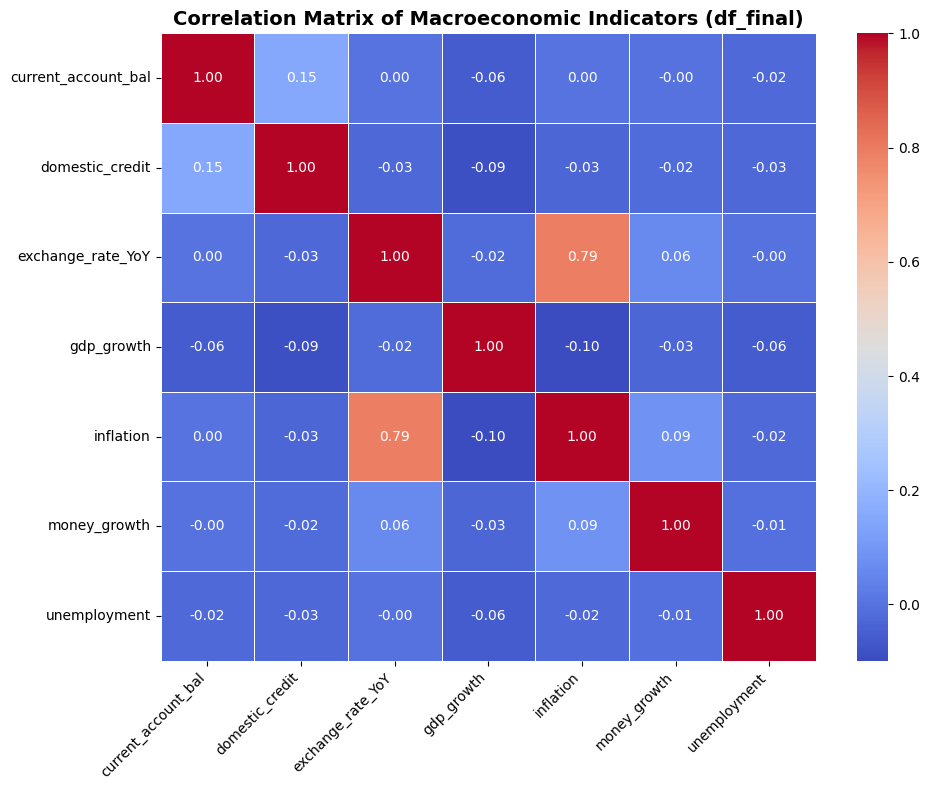

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the Spark DataFrame to a Pandas DataFrame for correlation calculation and plotting
pdf_final = df_final.toPandas()

# Define the list of variables for the correlation matrix
# Note: 'exchange_rate' was transformed into 'exchange_rate_YoY'
variables_for_correlation = [
    'current_account_bal',
    'domestic_credit',
    'exchange_rate_YoY', # Using the transformed YoY variable
    'gdp_growth',
    'inflation',
    'money_growth',
    'unemployment'
]

# Select only the relevant columns for the correlation matrix
df_corr = pdf_final[variables_for_correlation]

# Calculate the correlation matrix
correlation_matrix = df_corr.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Macroeconomic Indicators (df_final)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 5. Outlier detection and Scaling

## Extreme values

## i. Detect Outliers

=== OUTLIER DETECTION SUMMARY REPORT ===
+----------+-------------------+-----+-----------+------------+--------------+--------+--------+-----------+
|% Outliers|Feature            |IQR  |Lower Bound|Median (50%)|Outliers Count|Q1 (25%)|Q3 (75%)|Upper Bound|
+----------+-------------------+-----+-----------+------------+--------------+--------+--------+-----------+
|9.84      |current_account_bal|8.07 |-19.03     |-2.97       |534           |-6.92   |1.15    |13.26      |
|6.06      |domestic_credit    |46.55|-53.58     |34.0        |329           |16.24   |62.79   |132.61     |
|12.7      |exchange_rate_YoY  |7.1  |-10.82     |0.38        |689           |-0.16   |6.94    |17.59      |
|7.34      |gdp_growth         |4.56 |-5.45      |3.73        |398           |1.39    |5.94    |12.78      |
|10.75     |inflation          |7.09 |-8.67      |4.37        |583           |1.96    |9.05    |19.69      |
|8.07      |money_growth       |13.66|-14.28     |11.97       |438           |6.21    |

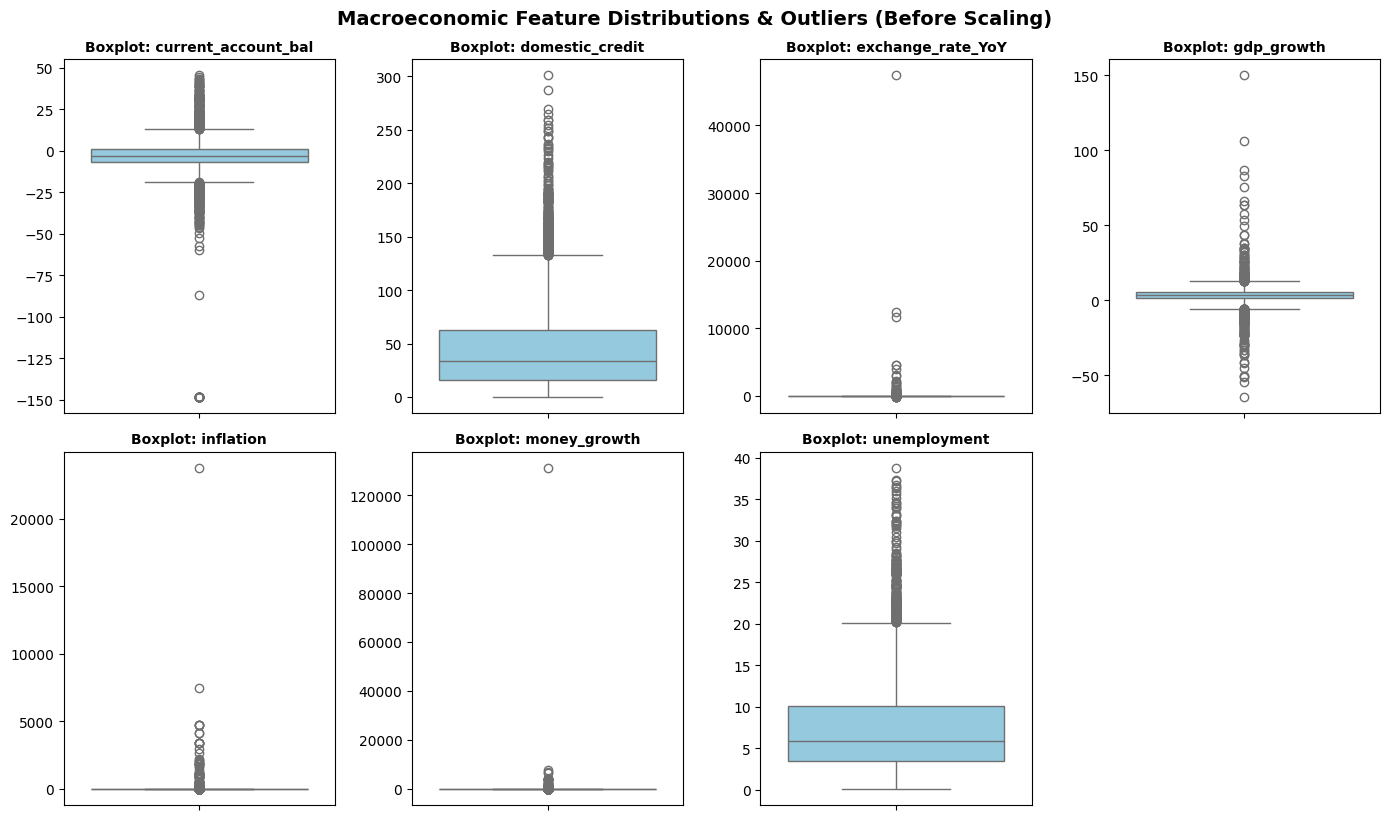

In [ ]:
# # 1. Read input dataset natively into PySpark
# raw_file_path_1 = os.path.join(
#     output_folder, 'dataset_imputed_correctly_spark.csv'
# )
# df = spark.read.csv(raw_file_path_1, header=True, inferSchema=True)

df = df_final

features = [
    'current_account_bal',
    'domestic_credit',
    'exchange_rate_YoY',
    'gdp_growth',
    'inflation',
    'money_growth',
    'unemployment',
]

total_count = df.count()
outlier_data = []

# 2. IQR Outlier Detection using PySpark
for col in features:
  # Compute exact quantiles (Q1, Median, Q3) natively in PySpark
  quantiles = df.approxQuantile(col, [0.25, 0.50, 0.75], 0.0)
  q1, median, q3 = quantiles[0], quantiles[1], quantiles[2]
  iqr = q3 - q1
  lower_bound = q1 - 1.5 * iqr
  upper_bound = q3 + 1.5 * iqr

  # Filter and count outliers natively in PySpark
  outliers_count = df.filter(
      (F.col(col) < lower_bound) | (F.col(col) > upper_bound)
  ).count()
  pct_outliers = (outliers_count / total_count) * 100

  outlier_data.append({
      'Feature': col,
      'Q1 (25%)': round(q1, 2),
      'Median (50%)': round(median, 2),
      'Q3 (75%)': round(q3, 2),
      'IQR': round(iqr, 2),
      'Lower Bound': round(lower_bound, 2),
      'Upper Bound': round(upper_bound, 2),
      'Outliers Count': outliers_count,
      '% Outliers': round(pct_outliers, 2),
  })

# Convert summary list to PySpark DataFrame
df_outlier_summary = spark.createDataFrame(outlier_data)
print('=== OUTLIER DETECTION SUMMARY REPORT ===')
df_outlier_summary.show(truncate=False)

# 3. Save Outlier Summary to CSV natively using PySpark
df_outlier_summary.coalesce(1).write.csv(
    'outlier_detection_summary.csv', header=True, mode='overwrite'
)

# 4. Generate & Save Visualizations (Boxplots)
# Collect feature vectors into memory strictly for rendering Matplotlib boxplots
pdf = df.select(features).toPandas()

plt.figure(figsize=(14, 8))
for i, col in enumerate(features, 1):
  plt.subplot(2, 4, i)
  sns.boxplot(y=pdf[col], color='skyblue')
  plt.title(f'Boxplot: {col}', fontsize=10, fontweight='bold')
  plt.ylabel('')
  plt.tight_layout()

plt.suptitle(
    'Macroeconomic Feature Distributions & Outliers (Before Scaling)',
    y=1.02,
    fontsize=14,
    fontweight='bold',
)
plt.savefig('outliers_boxplots.png', bbox_inches='tight', dpi=300)
plt.show()

#Exreme values

In [ ]:


# Define paths
output_folder = '/content/drive/MyDrive/Assignment Big Datasets'
file_path = os.path.join(output_folder, 'dataset_imputed_correctly_spark.csv')

df_imputed = pd.read_csv(file_path)

attribute_cols = [
    'exchange_rate_YoY',
    'inflation',
    'money_growth',
]

# Build structured DataFrame
records = []
for col in attribute_cols:
    top_3 = df_imputed.nlargest(5, col)[['Country', 'Year', col]]
    for rank, (_, row) in enumerate(top_3.iterrows(), start=1):
        records.append({
            'Attribute': col,
            'Rank': rank,
            'Country': row['Country'],
            'Year': int(row['Year']),
            'Value': round(row[col], 4),
        })

df_top3_summary = pd.DataFrame(records)

# Display table in Jupyter/Colab
display(df_top3_summary)

,Attribute,Rank,Country,Year,Value
0,exchange_rate_YoY,1,"Congo, Dem. Rep.",1994,47390.8997
1,exchange_rate_YoY,2,Suriname,1994,12362.7875
2,exchange_rate_YoY,3,Myanmar,2012,11667.8301
3,exchange_rate_YoY,4,Angola,1996,4555.2174
4,exchange_rate_YoY,5,Angola,1995,4521.0696
5,inflation,1,"Congo, Dem. Rep.",1994,23773.1318
6,inflation,2,Peru,1990,7481.6636
7,inflation,3,Ukraine,1990,4734.9143
8,inflation,4,Ukraine,1991,4734.9143
9,inflation,5,Ukraine,1992,4734.9143


## ii. Robust Scaling

In [ ]:
# Step A: Assemble feature columns into a dense vector format required by PySpark MLlib
assembler = VectorAssembler(inputCols=features, outputCol="features_vector")
df_vectorized = assembler.transform(df)

# Step B: Fit and Transform using PySpark's native RobustScaler
scaler = RobustScaler(
    inputCol="features_vector",
    outputCol="scaled_features_vector",
    withScaling=True,
    withCentering=True,
    lower=0.25,
    upper=0.75,
)
scaler_model = scaler.fit(df_vectorized)
df_scaled_vector = scaler_model.transform(df_vectorized)

# Step C: Unpack scaled vector elements back into their individual continuous column names
metadata_cols = [c for c in df.columns if c not in features]
df_scaled_spark = df_scaled_vector

for i, col_name in enumerate(features):
  extract_elem = F.udf(lambda v, idx=i: float(v[idx]), "double")
  df_scaled_spark = df_scaled_spark.withColumn(
      col_name, extract_elem(F.col("scaled_features_vector"))
  )

# Step D: Retain clean column structure (Metadata + Scaled Features)
df_scaled_spark = df_scaled_spark.select(metadata_cols + features)

# Save to drive using PySpark
output_robust = os.path.join(output_folder, "dataset_robust_scale_spark.csv")
df_scaled_spark.toPandas().to_csv(output_robust, index=False)

df_scaled_spark.show(5)

print("Robust Scaled Dataset is saved on Google Drive")

+-------+-------+----+--------------------+------------------+--------------------+-------------------+------------------+-----------------+------------------+
|Country|economy|Year| current_account_bal|   domestic_credit|   exchange_rate_YoY|         gdp_growth|         inflation|     money_growth|      unemployment|
+-------+-------+----+--------------------+------------------+--------------------+-------------------+------------------+-----------------+------------------+
|Albania|    ALB|1990|-0.35179314530277034|0.0735115520983987|-0.05055929710966535| -2.925099329168869| 31.32863333662371|2.924604395364012| 0.672320624437106|
|Albania|    ALB|1991| -1.5190278938990736|0.0735115520983987|-0.05055929710966535|-6.9790352652846535| 31.32863333662371|2.924604395364012| 0.672320624437106|
|Albania|    ALB|1992| -0.5917667369612266|0.0735115520983987|-0.05055929710966535|-2.3996092022863924| 31.32863333662371|2.924604395364012| 3.629840888622036|
|Albania|    ALB|1993|  0.52406001553043

## iii. Verify the Robust Scaling

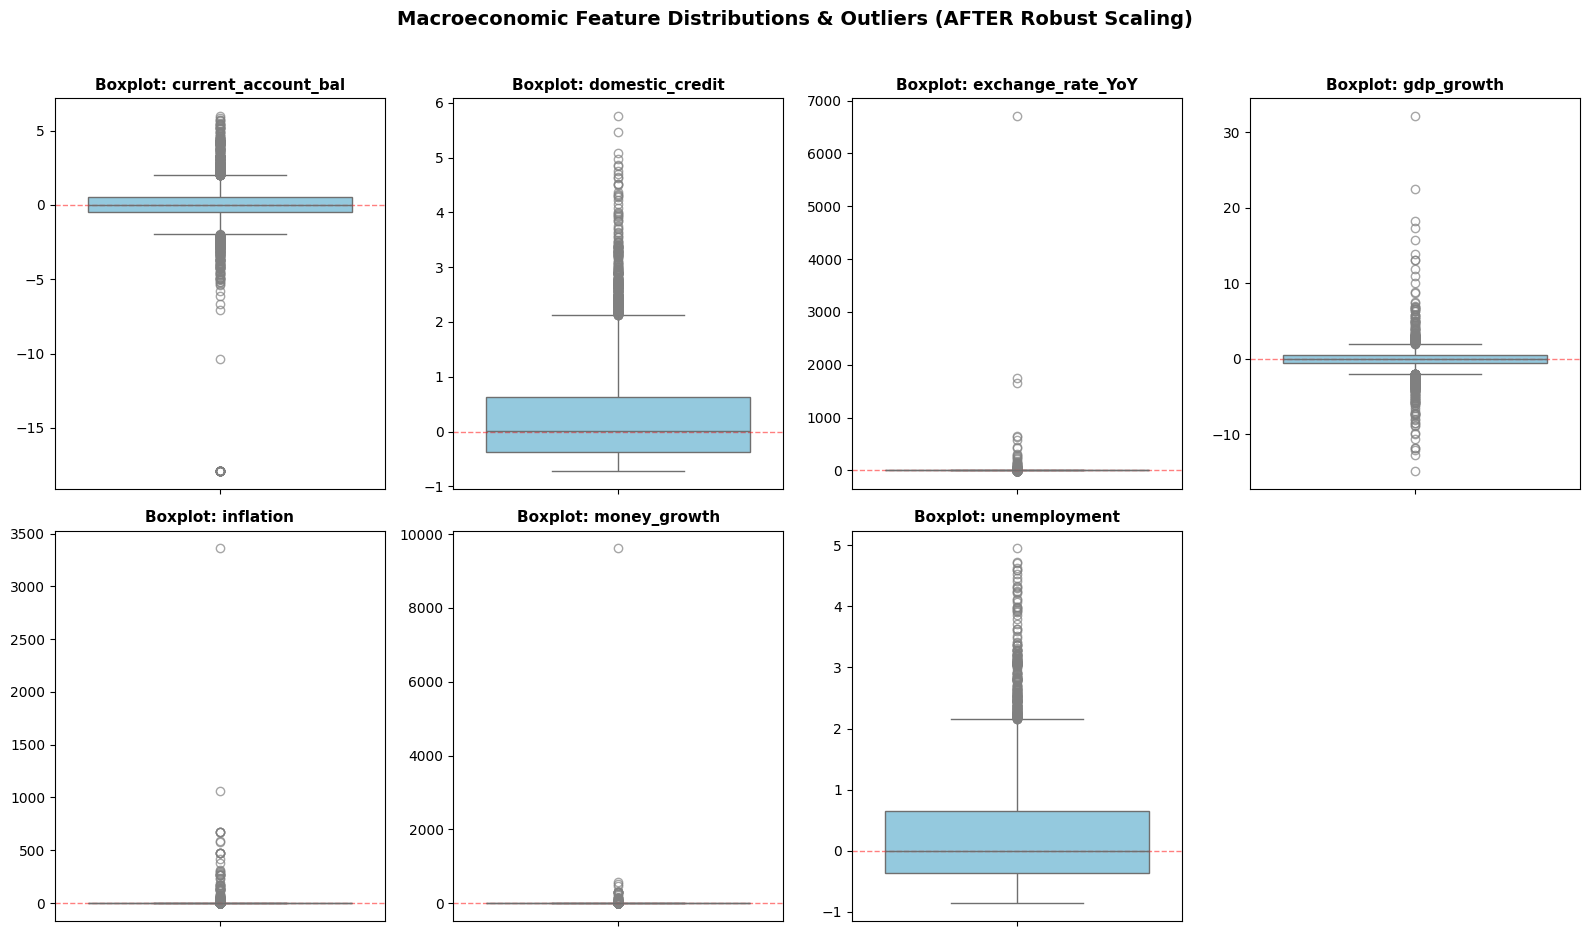

In [ ]:
# 1. Read your scaled PySpark output (converted to pandas)
# Replace 'df_scaled_spark' with your actual scaled DataFrame name if it's already in memory as pandas
df_plot = df_scaled_spark.toPandas()


# 2. Define features list
features = [
    'current_account_bal',
    'domestic_credit',
    'exchange_rate_YoY',
    'gdp_growth',
    'inflation',
    'money_growth',
    'unemployment',
]

# 3. Setup 2x4 Grid Subplots (matching your exact visual style)
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 9.5))
axes = axes.flatten()  # Flatten matrix to 1D array for easy iteration

# Color palette matching your screenshot (skyblue / light blue)
box_color = 'skyblue'

for i, col in enumerate(features):
  sns.boxplot(
      y=df_plot[col],
      ax=axes[i],
      color=box_color,
      flierprops=dict(
          marker='o', markerfacecolor='none', markeredgecolor='gray', alpha=0.7
      ),
  )

  # Title for each subplot
  axes[i].set_title(f'Boxplot: {col}', fontsize=11, fontweight='bold')
  axes[i].set_ylabel('')
  axes[i].set_xlabel('')

  # Add horizontal reference line at y=0 (scaled median baseline)
  axes[i].axhline(0, color='red', linestyle='--', alpha=0.5, linewidth=1)

# 4. Hide the 8th unused subplot (row 2, col 4)
fig.delaxes(axes[7])

# 5. Overall Title and Layout Adjustments
fig.suptitle(
    'Macroeconomic Feature Distributions & Outliers (AFTER Robust Scaling)',
    fontsize=14,
    fontweight='bold',
    y=0.98,
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Histogram

# Histogram before scaled


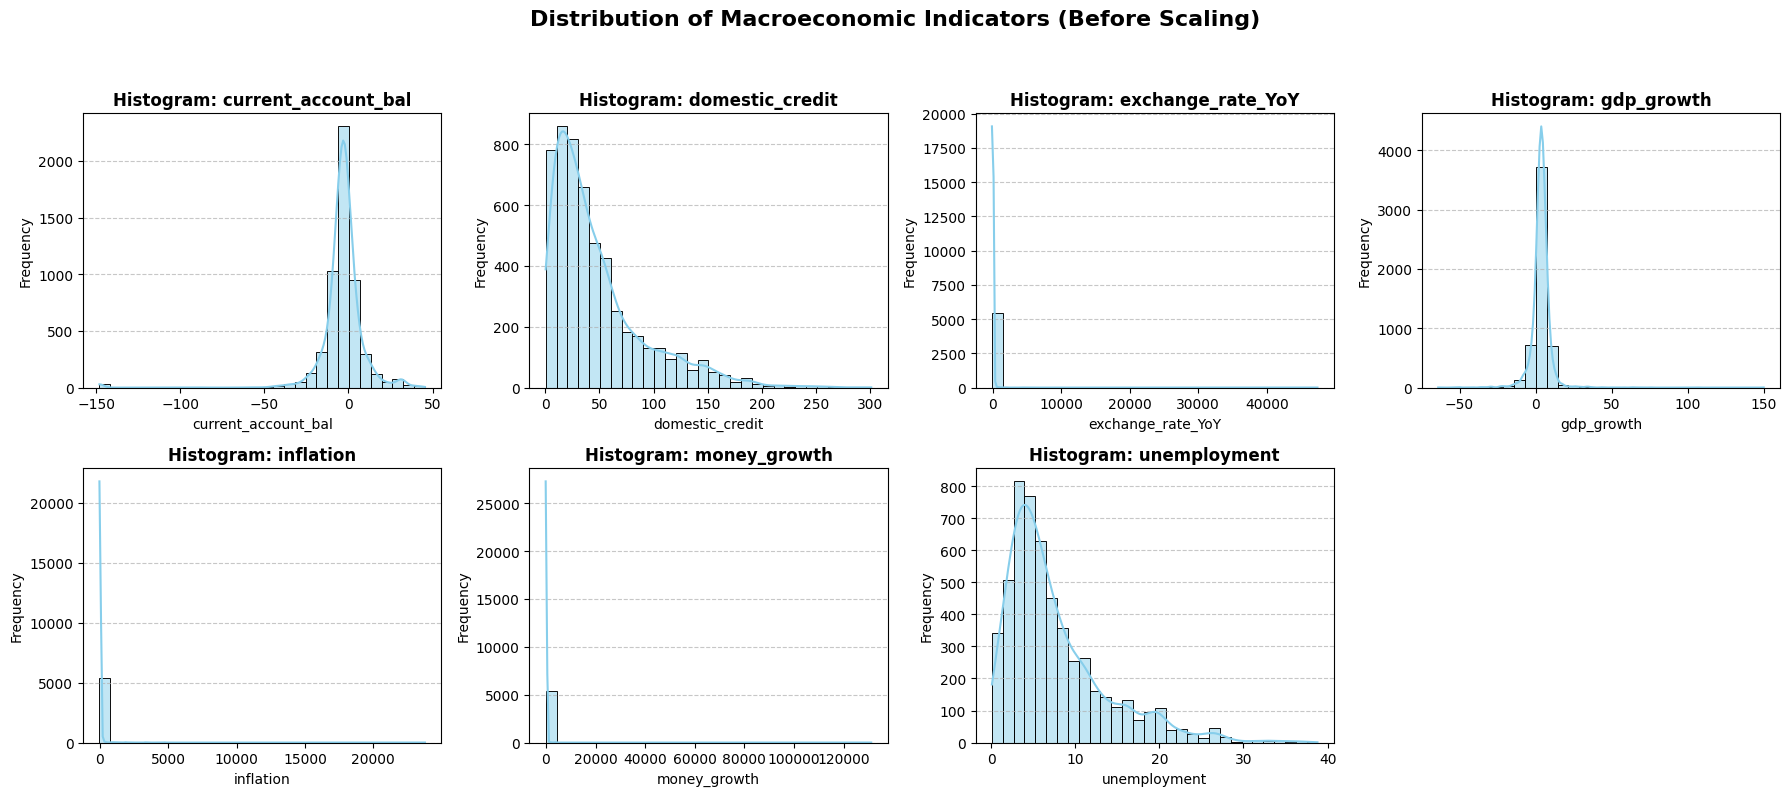

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the Spark DataFrame to a Pandas DataFrame for plotting
pdf_final = df_final.toPandas()

# Define the list of variables for which to create histograms
variables_to_plot = [
    'current_account_bal',
    'domestic_credit',
    'exchange_rate_YoY',
    'gdp_growth',
    'inflation',
    'money_growth',
    'unemployment'
]

# Determine the number of rows and columns for the subplots
n_vars = len(variables_to_plot)
rows = (n_vars + 3) // 4  # 4 plots per row

plt.figure(figsize=(18, 4 * rows)) # Adjust figure size dynamically
plt.suptitle('Distribution of Macroeconomic Indicators (Before Scaling)', fontsize=16, fontweight='bold', y=1.02)

for i, col in enumerate(variables_to_plot, 1):
    plt.subplot(rows, 4, i)
    sns.histplot(pdf_final[col], kde=True, color='skyblue', bins=30)
    plt.title(f'Histogram: {col}', fontsize=12, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

# Histogram after scaled

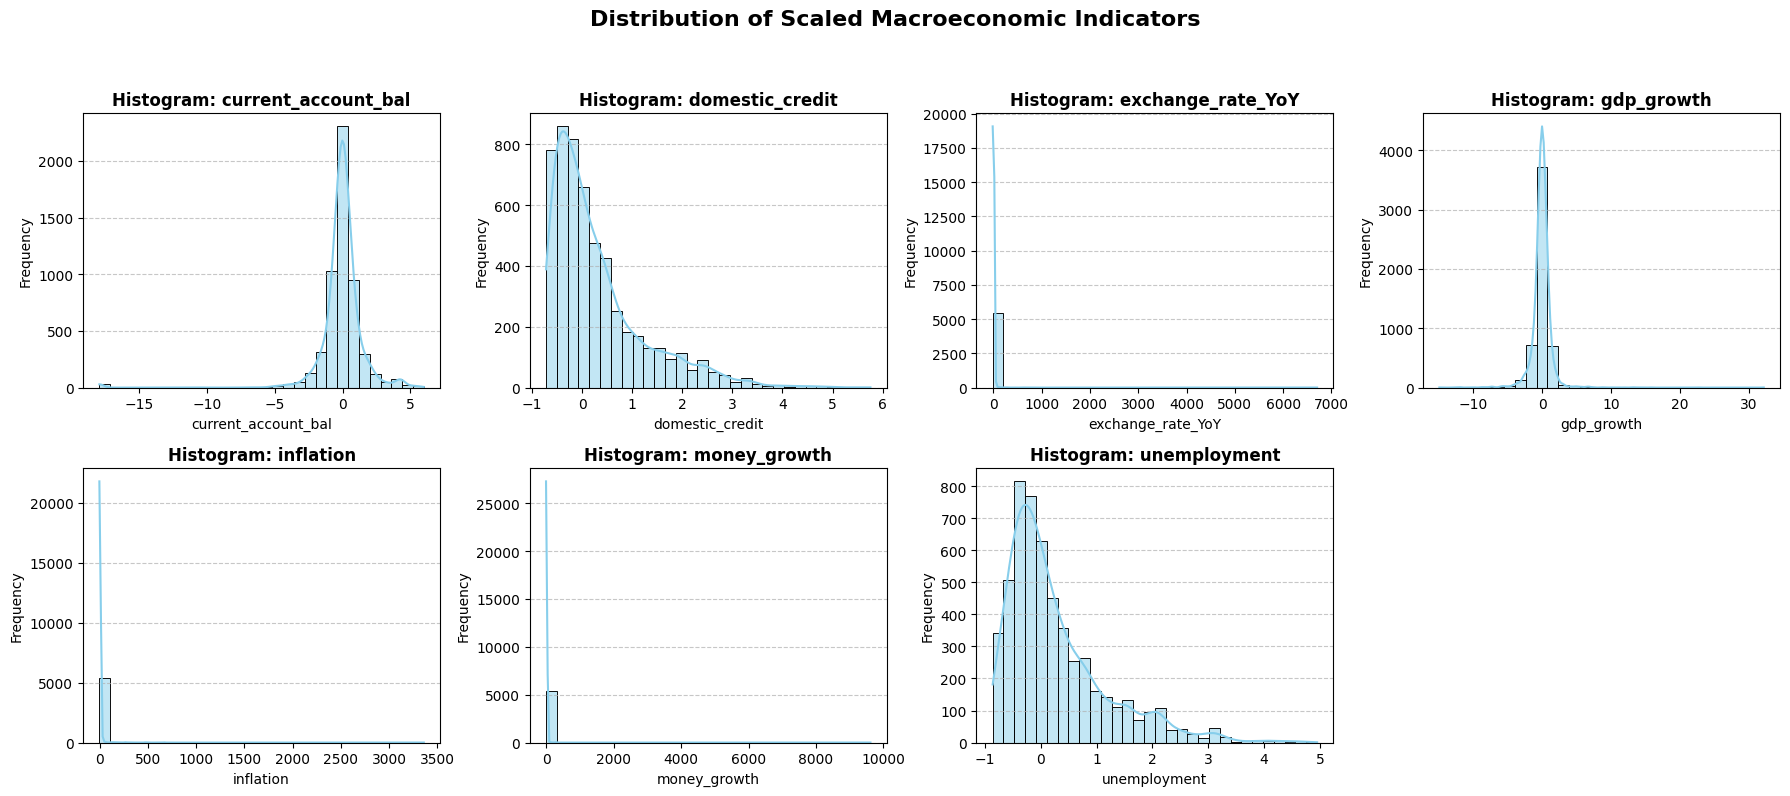

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the Spark DataFrame to a Pandas DataFrame for plotting
pdf_scaled = df_scaled_spark.toPandas()

# Define the list of variables for which to create histograms
variables_to_plot = [
    'current_account_bal',
    'domestic_credit',
    'exchange_rate_YoY',
    'gdp_growth',
    'inflation',
    'money_growth',
    'unemployment'
]

# Determine the number of rows and columns for the subplots
n_vars = len(variables_to_plot)
rows = (n_vars + 3) // 4  # 4 plots per row

plt.figure(figsize=(18, 4 * rows)) # Adjust figure size dynamically
plt.suptitle('Distribution of Scaled Macroeconomic Indicators', fontsize=16, fontweight='bold', y=1.02)

for i, col in enumerate(variables_to_plot, 1):
    plt.subplot(rows, 4, i)
    sns.histplot(pdf_scaled[col], kde=True, color='skyblue', bins=30)
    plt.title(f'Histogram: {col}', fontsize=12, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

# 5. Data Transformation

## i. Dealing with text attributes

The categorical spatial descriptors Country and economy were excluded from the model training matrix (X)

In [ ]:
# Import the Robust Scaled file from drive

raw_file_path_2 = os.path.join(output_folder, 'dataset_robust_scale_spark.csv')
df_spark = spark.read.csv(
    raw_file_path_2, header=True, inferSchema=True)

# 1. Define Metadata Identifiers (Keep for indexing, plotting, and splitting)
metadata_cols = ['Country', 'economy', 'Year']

# 2. Define Model Input Features (X)
feature_cols = [
    'current_account_bal',
    'domestic_credit',
    'exchange_rate_YoY',
    'gdp_growth',
    'inflation',
    'money_growth',
    'unemployment',
]

# Extract feature matrix X and target y (once target is constructed)

df_X_spark = df_spark.select(feature_cols)
df_metadata_spark = df_spark.select(metadata_cols)

print(
    f'Feature Matrix X Shape: ({df_X_spark.count()},'
    f' {len(df_X_spark.columns)})'
)
print(
    f'Metadata Matrix Shape: ({df_metadata_spark.count()},'
    f' {len(df_metadata_spark.columns)})'
)
df_X_spark.show(5)


Feature Matrix X Shape: (5425, 7)
Metadata Matrix Shape: (5425, 3)
+--------------------+------------------+--------------------+-------------------+------------------+-----------------+------------------+
| current_account_bal|   domestic_credit|   exchange_rate_YoY|         gdp_growth|         inflation|     money_growth|      unemployment|
+--------------------+------------------+--------------------+-------------------+------------------+-----------------+------------------+
|-0.35179314530277034|0.0735115520983987|-0.05055929710966535| -2.925099329168869| 31.32863333662371|2.924604395364012| 0.672320624437106|
| -1.5190278938990736|0.0735115520983987|-0.05055929710966535|-6.9790352652846535| 31.32863333662371|2.924604395364012| 0.672320624437106|
| -0.5917667369612266|0.0735115520983987|-0.05055929710966535|-2.3996092022863924| 31.32863333662371|2.924604395364012| 3.629840888622036|
|  0.5240600155304336|0.0735115520983987|   5.046466948800976|  1.284721746511036|11.39869013573825

## ii. Directional Allignment

In [ ]:
# 1. Define features where high values indicate LOW risk (good economic health)
# Note: Adjust column names if they differ in your exact dataframe
positive_indicators = ["gdp_growth", "current_account_bal"]

# 2. Iterate through columns and invert the sign of positive indicators
aligned_cols = []
for col in df_X_spark.columns:
    if col in positive_indicators:
        # Invert direction: High positive values become negative (Low Risk)
        aligned_cols.append((F.col(col) * -1.0).alias(col))
    else:
        # Keep original direction: High values already mean High Risk
        aligned_cols.append(F.col(col))

# 3. Create the directionally aligned dataframe
df_aligned_spark = df_X_spark.select(aligned_cols)

# Display sample output to confirm sign transformation
df_aligned_spark.show(5)

+-------------------+------------------+--------------------+-------------------+------------------+-----------------+------------------+
|current_account_bal|   domestic_credit|   exchange_rate_YoY|         gdp_growth|         inflation|     money_growth|      unemployment|
+-------------------+------------------+--------------------+-------------------+------------------+-----------------+------------------+
|0.35179314530277034|0.0735115520983987|-0.05055929710966535|  2.925099329168869| 31.32863333662371|2.924604395364012| 0.672320624437106|
| 1.5190278938990736|0.0735115520983987|-0.05055929710966535| 6.9790352652846535| 31.32863333662371|2.924604395364012| 0.672320624437106|
| 0.5917667369612266|0.0735115520983987|-0.05055929710966535| 2.3996092022863924| 31.32863333662371|2.924604395364012| 3.629840888622036|
|-0.5240600155304336|0.0735115520983987|   5.046466948800976| -1.284721746511036|11.398690135738256|2.924604395364012|2.9159411588111683|
|  0.664516271733491|0.07351155209

# Devlop CMRI using Equal Weight Method


In [ ]:
# 1. Identify feature columns from df_aligned_spark
feature_cols = df_aligned_spark.columns
num_features = len(feature_cols)

# 2. Compute Equal-Weighted CMRI (Mean across robust-scaled, aligned features)
# Each feature contributes equally with an exact weight of 1 / N (1 / 7 ≈ 14.29%)
cmri_expr = sum([F.col(c) for c in feature_cols]) / num_features

df_cmri = df_aligned_spark.withColumn("cmri_score", cmri_expr)

# 3. Print Weight Allocation Breakdown
print("=" * 60)
print(f"EQUAL-WEIGHTED CMRI ALLOCATION TABLE (Total Features: {num_features})")
print("=" * 60)
print(f"{'Feature Name':<25} | {'Weight Formula':<15} | {'Decimal Weight':<15} | {'Percentage'}")
print("-" * 60)
for col_name in feature_cols:
    print(f"{col_name:<25} | 1 / {num_features:<11} | {1/num_features:<15.4f} | {(1/num_features)*100:.2f}%")
print("=" * 60)

# Display sample output
df_cmri.select("cmri_score", *feature_cols).show(5)

EQUAL-WEIGHTED CMRI ALLOCATION TABLE (Total Features: 7)
Feature Name              | Weight Formula  | Decimal Weight  | Percentage
------------------------------------------------------------
current_account_bal       | 1 / 7           | 0.1429          | 14.29%
domestic_credit           | 1 / 7           | 0.1429          | 14.29%
exchange_rate_YoY         | 1 / 7           | 0.1429          | 14.29%
gdp_growth                | 1 / 7           | 0.1429          | 14.29%
inflation                 | 1 / 7           | 0.1429          | 14.29%
money_growth              | 1 / 7           | 0.1429          | 14.29%
unemployment              | 1 / 7           | 0.1429          | 14.29%
+------------------+-------------------+------------------+--------------------+-------------------+------------------+-----------------+------------------+
|        cmri_score|current_account_bal|   domestic_credit|   exchange_rate_YoY|         gdp_growth|         inflation|     money_growth|      unemployme

# Create the dataset for machine learning model

### NOTE - The interactive dashboard will be at another Colab file

Here the the Country, economy and Year columns are added, directonal change reversed and CMRI index added to create a dataset to be sent to visualisation purposes

In [ ]:
# 1. Read the robust scaled dataset (contains Country, economy, Year + features in natural polarity)
raw_file_path_2 = os.path.join(output_folder, 'dataset_robust_scale_spark.csv')
df_scaled_meta = spark.read.csv(raw_file_path_2, header=True, inferSchema=True)

# 2. Extract cmri_score column from df_cmri
cmri_only = df_cmri.select("cmri_score")

# 3. Add row IDs to merge metadata dataframe with cmri_score row-by-row
df_meta_id = df_scaled_meta.withColumn("row_id", monotonically_increasing_id())
cmri_id = cmri_only.withColumn("row_id", monotonically_increasing_id())

# 4. Join metadata + original features + cmri_score
df_dashboard_spark = df_meta_id.join(cmri_id, on="row_id").drop("row_id")

# 5. Save to Google Drive as CSV for Interactive Dashboarding
dashboard_csv_path = os.path.join(output_folder, "cmri_dashboard_dataset.csv")
df_dashboard_spark.toPandas().to_csv(dashboard_csv_path, index=False)

print(f"SUCCESS! Dashboard dataset created and saved to: {dashboard_csv_path}")
print("Columns included:", df_dashboard_spark.columns)
df_dashboard_spark.show(5)

SUCCESS! Dashboard dataset created and saved to: /content/drive/MyDrive/Assignment Big Datasets/cmri_dashboard_dataset.csv
Columns included: ['Country', 'economy', 'Year', 'current_account_bal', 'domestic_credit', 'exchange_rate_YoY', 'gdp_growth', 'inflation', 'money_growth', 'unemployment', 'cmri_score']
+-------+-------+----+--------------------+------------------+--------------------+-------------------+------------------+-----------------+------------------+------------------+
|Country|economy|Year| current_account_bal|   domestic_credit|   exchange_rate_YoY|         gdp_growth|         inflation|     money_growth|      unemployment|        cmri_score|
+-------+-------+----+--------------------+------------------+--------------------+-------------------+------------------+-----------------+------------------+------------------+
|Albania|    ALB|1990|-0.35179314530277034|0.0735115520983987|-0.05055929710966535| -2.925099329168869| 31.32863333662371|2.924604395364012| 0.672320624437

# Define CMRI categories and threshold

In [ ]:


# 1. Compute exact percentile thresholds from df_cmri for 3 categories (Tertiles)
quantiles = df_cmri.approxQuantile("cmri_score", [1/3, 2/3], 0.0)
p33, p67 = quantiles[0], quantiles[1]

# 2. Assign 3 CMRI Risk Categories using F.when()
df_cmri = df_cmri.withColumn(
    "cmri_risk_category",
    F.when(F.col("cmri_score") <= p33, F.lit("Low Risk"))
     .when((F.col("cmri_score") > p33) & (F.col("cmri_score") <= p67), F.lit("Moderate Risk"))
     .otherwise(F.lit("High Risk"))
)

# 3. Print Category Distribution Summary
print("=" * 60)
print("CMRI RISK CATEGORY THRESHOLDS & DISTRIBUTION")
print("=" * 60)
print(f"Low Risk      (<= 33.33rd Pct)  : CMRI <= {p33:.4f}")
print(f"Moderate Risk (33.33rd - 66.67th): {p33:.4f} < CMRI <= {p67:.4f}")
print(f"High Risk     (> 66.67th Pct)   : CMRI > {p67:.4f}")
print("=" * 60)

# Display distribution breakdown
df_cmri.groupBy("cmri_risk_category").count().orderBy(F.col("count").desc()).show()
df_cmri.show(5)

CMRI RISK CATEGORY THRESHOLDS & DISTRIBUTION
Low Risk      (<= 33.33rd Pct)  : CMRI <= 0.0125
Moderate Risk (33.33rd - 66.67th): 0.0125 < CMRI <= 0.3522
High Risk     (> 66.67th Pct)   : CMRI > 0.3522
+------------------+-----+
|cmri_risk_category|count|
+------------------+-----+
|          Low Risk| 1809|
|     Moderate Risk| 1808|
|         High Risk| 1808|
+------------------+-----+

+-------------------+------------------+--------------------+-------------------+------------------+-----------------+------------------+------------------+------------------+
|current_account_bal|   domestic_credit|   exchange_rate_YoY|         gdp_growth|         inflation|     money_growth|      unemployment|        cmri_score|cmri_risk_category|
+-------------------+------------------+--------------------+-------------------+------------------+-----------------+------------------+------------------+------------------+
|0.35179314530277034|0.0735115520983987|-0.05055929710966535|  2.925099329168869|

# Encode the labels

In [ ]:


# 1. Compute exact percentile thresholds from df_cmri for 3 categories (Tertiles)
quantiles = df_cmri.approxQuantile("cmri_score", [1/3, 2/3], 0.0)
p33, p67 = quantiles[0], quantiles[1]

# 2. Assign 3 CMRI Risk Categories using F.when()
df_cmri = df_cmri.withColumn(
    "cmri_risk_category",
    F.when(F.col("cmri_score") <= p33, F.lit("Low Risk"))
     .when((F.col("cmri_score") > p33) & (F.col("cmri_score") <= p67), F.lit("Moderate Risk"))
     .otherwise(F.lit("High Risk"))
)

# 3. Label / Encode the Categories (Low Risk = 0, Moderate Risk = 1, High Risk = 2)
label_mapping = F.create_map([
    F.lit("Low Risk"), F.lit(0),
    F.lit("Moderate Risk"), F.lit(1),
    F.lit("High Risk"), F.lit(2)
])
df_cmri = df_cmri.withColumn("label", label_mapping[F.col("cmri_risk_category")])

# 4. Print Category Distribution & Encoded Labels Summary
print("=" * 60)
print("CMRI RISK CATEGORY THRESHOLDS & DISTRIBUTION")
print("=" * 60)
print(f"Low Risk (0)      (<= 33.33rd Pct)  : CMRI <= {p33:.4f}")
print(f"Moderate Risk (1) (33.33rd - 66.67th): {p33:.4f} < CMRI <= {p67:.4f}")
print(f"High Risk (2)     (> 66.67th Pct)   : CMRI > {p67:.4f}")
print("=" * 60)

# Display distribution breakdown with numeric labels
df_cmri.groupBy("cmri_risk_category", "label").count().orderBy("label").show()
df_cmri.show(5)

dashboard_csv_path = os.path.join(output_folder, "final_dataset.csv")
df_cmri.toPandas().to_csv(dashboard_csv_path, index=False)



CMRI RISK CATEGORY THRESHOLDS & DISTRIBUTION
Low Risk (0)      (<= 33.33rd Pct)  : CMRI <= 0.0125
Moderate Risk (1) (33.33rd - 66.67th): 0.0125 < CMRI <= 0.3522
High Risk (2)     (> 66.67th Pct)   : CMRI > 0.3522
+------------------+-----+-----+
|cmri_risk_category|label|count|
+------------------+-----+-----+
|          Low Risk|    0| 1809|
|     Moderate Risk|    1| 1808|
|         High Risk|    2| 1808|
+------------------+-----+-----+

+-------------------+------------------+--------------------+-------------------+------------------+-----------------+------------------+------------------+------------------+-----+
|current_account_bal|   domestic_credit|   exchange_rate_YoY|         gdp_growth|         inflation|     money_growth|      unemployment|        cmri_score|cmri_risk_category|label|
+-------------------+------------------+--------------------+-------------------+------------------+-----------------+------------------+------------------+------------------+-----+
|0.351793

# Create a features vector

In [ ]:


# 1. Define input feature column names
feature_cols = [
    'current_account_bal',
    'domestic_credit',
    'exchange_rate_YoY',
    'gdp_growth',
    'inflation',
    'money_growth',
    'unemployment'
]

# 2. Initialize VectorAssembler
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

# 3. Transform df_cmri to create the ML-ready dataset
df_ml = assembler.transform(df_cmri)

# 4. Verify the structure
print("=" * 60)
print("FEATURE VECTOR ASSEMBLY COMPLETE")
print("=" * 60)
df_ml.select("features", "cmri_risk_category", "label").show(5, truncate=False)

FEATURE VECTOR ASSEMBLY COMPLETE
+-------------------------------------------------------------------------------------------------------------------------------------+------------------+-----+
|features                                                                                                                             |cmri_risk_category|label|
+-------------------------------------------------------------------------------------------------------------------------------------+------------------+-----+
|[0.35179314530277034,0.0735115520983987,-0.05055929710966535,2.925099329168869,31.32863333662371,2.924604395364012,0.672320624437106]|High Risk         |2    |
|[1.5190278938990736,0.0735115520983987,-0.05055929710966535,6.9790352652846535,31.32863333662371,2.924604395364012,0.672320624437106]|High Risk         |2    |
|[0.5917667369612266,0.0735115520983987,-0.05055929710966535,2.3996092022863924,31.32863333662371,2.924604395364012,3.629840888622036]|High Risk         |2    |
|

#Class Balance of the Label

In [ ]:
# 1. Calculate count and percentage per class
total_count = df_ml.count()

class_balance = df_ml.groupBy("label") \
    .agg(
        F.count("*").alias("count"),
        F.round((F.count("*") / total_count) * 100, 2).alias("percentage_%")
    ) \
    .orderBy("label")

# 2. Display the class balance
print("=" * 60)
print("CLASS BALANCE ANALYSIS (LABEL COLUMN)")
print("=" * 60)
class_balance.show()

CLASS BALANCE ANALYSIS (LABEL COLUMN)
+-----+-----+------------+
|label|count|percentage_%|
+-----+-----+------------+
|    0| 1809|       33.35|
|    1| 1808|       33.33|
|    2| 1808|       33.33|
+-----+-----+------------+



# Do the Train Test Split

In [ ]:
# Split dataset into 80% training set and 20% testing set
train_df, test_df = df_ml.randomSplit([0.8, 0.2], seed=42)

# Verify counts

print("TRAIN / TEST SPLIT COMPLETED")

print(f"Training Set Records : {train_df.count()}")
print(f"Testing Set Records  : {test_df.count()}")


TRAIN / TEST SPLIT COMPLETED
Training Set Records : 4381
Testing Set Records  : 1044


# Run the Logistic Regression Model


## 1. Train Logistic Regression

In [ ]:
# Initialize Multinomial Logistic Regression
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=100
)

# Fit the model on the training set
print("Training Logistic Regression model...")
lr_model = lr.fit(train_df)
print("✔ Model training complete.")

Training Logistic Regression model...
✔ Model training complete.


## 2. Test Logistic Regression Model

In [ ]:
# Generate predictions on the test set
lr_predictions = lr_model.transform(test_df)

# Display sample predictions comparing true labels with model predictions
print("--- LOGISTIC REGRESSION PREDICTIONS SAMPLE ---")
lr_predictions.select("features", "label", "prediction", "probability").show(5, truncate=False)

--- LOGISTIC REGRESSION PREDICTIONS SAMPLE ---
+---------------------------------------------------------------------------------------------------------------------------------------------+-----+----------+--------------------------------------------------+
|features                                                                                                                                     |label|prediction|probability                                       |
+---------------------------------------------------------------------------------------------------------------------------------------------+-----+----------+--------------------------------------------------+
|[-5.751824501510333,-0.04595102505520363,-0.8948780395408824,1.6765823902636572,-0.3217245695107869,-0.17398384100542372,0.07310117081957372]|0    |0.0       |[1.0,3.782131499690331E-43,8.542132626377254E-72] |
|[-5.478571290490986,-0.04732980968162588,-0.692070089229018,-0.08327064577109705,-0.5938294990654049,-0.

## 3. Evaluate the model

In [ ]:


# Initialize PySpark Evaluators
eval_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
eval_prec = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
eval_rec = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")
eval_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")

# Calculate metrics on lr_predictions
acc_lr = eval_acc.evaluate(lr_predictions)
prec_lr = eval_prec.evaluate(lr_predictions)
rec_lr = eval_rec.evaluate(lr_predictions)
f1_lr = eval_f1.evaluate(lr_predictions)

# Display Summary
print("=" * 50)
print("LOGISTIC REGRESSION EVALUATION METRICS")
print("=" * 50)
print(f"Accuracy  : {acc_lr:.4f} ({acc_lr*100:.2f}%)")
print(f"Precision : {prec_lr:.4f}")
print(f"Recall    : {rec_lr:.4f}")
print(f"F1-Score  : {f1_lr:.4f}")
print("=" * 50)

LOGISTIC REGRESSION EVALUATION METRICS
Accuracy  : 0.9693 (96.93%)
Precision : 0.9694
Recall    : 0.9693
F1-Score  : 0.9694


# 4. Confusion Matrix

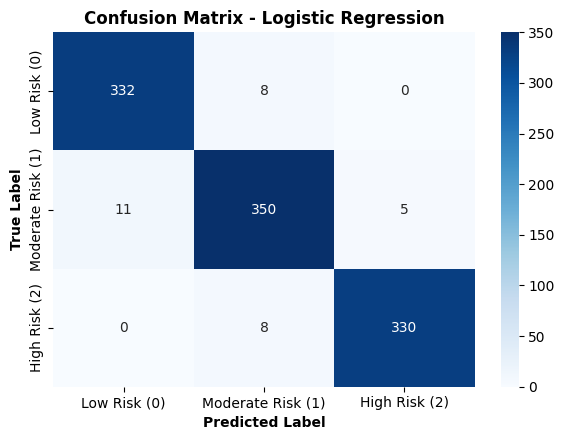

In [ ]:


# Extract labels and predictions to Pandas
pdf_lr = lr_predictions.select("label", "prediction").toPandas()

# Generate Confusion Matrix
cm_lr = confusion_matrix(pdf_lr["label"], pdf_lr["prediction"])
class_labels = ["Low Risk (0)", "Moderate Risk (1)", "High Risk (2)"]

# Plot Heatmap
plt.figure(figsize=(6, 4.5))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title('Confusion Matrix - Logistic Regression', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.tight_layout()
plt.show()

# Run the Decision Tree Model

## 1. Train the model

In [ ]:
# Initialize Decision Tree Classifier
dt = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="label",
    seed=42
)

# Fit the model on the training set
print("Training Decision Tree model...")
dt_model = dt.fit(train_df)
print("✔ Model training complete.")

Training Decision Tree model...
✔ Model training complete.


## 2. Run the model

In [ ]:
# Generate predictions on the test set
dt_predictions = dt_model.transform(test_df)

# Display sample predictions comparing true labels with model predictions
print("--- DECISION TREE PREDICTIONS SAMPLE ---")
dt_predictions.select("features", "label", "prediction", "probability").show(5, truncate=False)

--- DECISION TREE PREDICTIONS SAMPLE ---
+---------------------------------------------------------------------------------------------------------------------------------------------+-----+----------+-------------------------------------------------------------+
|features                                                                                                                                     |label|prediction|probability                                                  |
+---------------------------------------------------------------------------------------------------------------------------------------------+-----+----------+-------------------------------------------------------------+
|[-5.751824501510333,-0.04595102505520363,-0.8948780395408824,1.6765823902636572,-0.3217245695107869,-0.17398384100542372,0.07310117081957372]|0    |0.0       |[0.5646067415730337,0.34269662921348315,0.09269662921348315] |
|[-5.478571290490986,-0.04732980968162588,-0.692070089229018,-0.083

## 3. Run Performance Metrics

In [ ]:


# Initialize PySpark Evaluators
eval_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
eval_prec = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
eval_rec = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")
eval_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")

# Calculate metrics on dt_predictions
acc_dt = eval_acc.evaluate(dt_predictions)
prec_dt = eval_prec.evaluate(dt_predictions)
rec_dt = eval_rec.evaluate(dt_predictions)
f1_dt = eval_f1.evaluate(dt_predictions)

# Display Summary
print("=" * 50)
print("DECISION TREE EVALUATION METRICS")
print("=" * 50)
print(f"Accuracy  : {acc_dt:.4f} ({acc_dt*100:.2f}%)")
print(f"Precision : {prec_dt:.4f}")
print(f"Recall    : {rec_dt:.4f}")
print(f"F1-Score  : {f1_dt:.4f}")
print("=" * 50)

DECISION TREE EVALUATION METRICS
Accuracy  : 0.6571 (65.71%)
Precision : 0.6824
Recall    : 0.6571
F1-Score  : 0.6623


## 4. Confusion Matrix

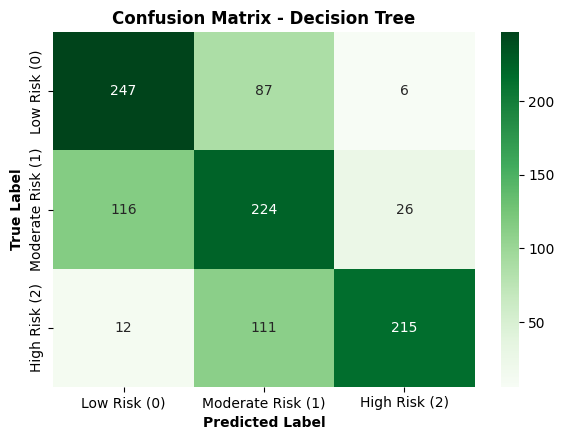

In [ ]:


# Extract labels and predictions to Pandas
pdf_dt = dt_predictions.select("label", "prediction").toPandas()

# Generate Confusion Matrix
cm_dt = confusion_matrix(pdf_dt["label"], pdf_dt["prediction"])
class_labels = ["Low Risk (0)", "Moderate Risk (1)", "High Risk (2)"]

# Plot Heatmap
plt.figure(figsize=(6, 4.5))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title('Confusion Matrix - Decision Tree', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.tight_layout()
plt.show()

# Run Random Forest Classifier

## 1. Train the model

In [ ]:


# Initialize Random Forest Classifier
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=100,
    seed=42
)

# Fit the model on the training set
print("Training Random Forest model...")
rf_model = rf.fit(train_df)
print("✔ Model training complete.")

Training Random Forest model...
✔ Model training complete.


## 2. Test the model

In [ ]:
# Generate predictions on the test set
rf_predictions = rf_model.transform(test_df)

# Display sample predictions comparing true labels with model predictions
print("--- RANDOM FOREST PREDICTIONS SAMPLE ---")
rf_predictions.select("features", "label", "prediction", "probability").show(5, truncate=False)

--- RANDOM FOREST PREDICTIONS SAMPLE ---
+---------------------------------------------------------------------------------------------------------------------------------------------+-----+----------+------------------------------------------------------------+
|features                                                                                                                                     |label|prediction|probability                                                 |
+---------------------------------------------------------------------------------------------------------------------------------------------+-----+----------+------------------------------------------------------------+
|[-5.751824501510333,-0.04595102505520363,-0.8948780395408824,1.6765823902636572,-0.3217245695107869,-0.17398384100542372,0.07310117081957372]|0    |0.0       |[0.614612592378304,0.22018941485440488,0.16519799276729114] |
|[-5.478571290490986,-0.04732980968162588,-0.692070089229018,-0.0832706

## Run Performance Matrices

In [ ]:

# Initialize PySpark Evaluators
eval_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
eval_prec = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
eval_rec = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")
eval_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")

# Calculate metrics on rf_predictions
acc_rf = eval_acc.evaluate(rf_predictions)
prec_rf = eval_prec.evaluate(rf_predictions)
rec_rf = eval_rec.evaluate(rf_predictions)
f1_rf = eval_f1.evaluate(rf_predictions)

# Display Summary
print("=" * 50)
print("RANDOM FOREST EVALUATION METRICS")
print("=" * 50)
print(f"Accuracy  : {acc_rf:.4f} ({acc_rf*100:.2f}%)")
print(f"Precision : {prec_rf:.4f}")
print(f"Recall    : {rec_rf:.4f}")
print(f"F1-Score  : {f1_rf:.4f}")
print("=" * 50)

RANDOM FOREST EVALUATION METRICS
Accuracy  : 0.7318 (73.18%)
Precision : 0.7354
Recall    : 0.7318
F1-Score  : 0.7328


## 4. Confusion Martix

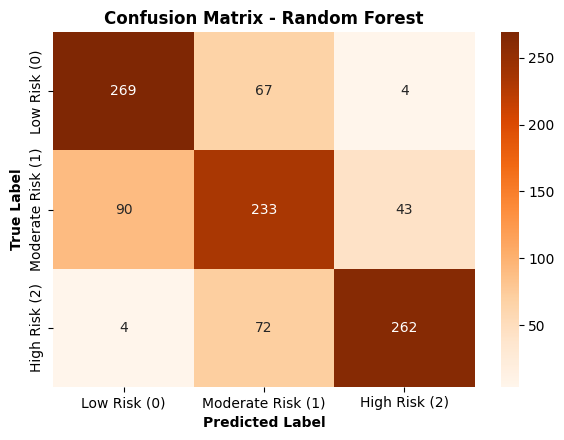

In [ ]:


# Extract labels and predictions to Pandas
pdf_rf = rf_predictions.select("label", "prediction").toPandas()

# Generate Confusion Matrix
cm_rf = confusion_matrix(pdf_rf["label"], pdf_rf["prediction"])
class_labels = ["Low Risk (0)", "Moderate Risk (1)", "High Risk (2)"]

# Plot Heatmap
plt.figure(figsize=(6, 4.5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title('Confusion Matrix - Random Forest', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.tight_layout()
plt.show()

#Comparison of the 3 models

MODEL PERFORMANCE COMPARISON SUMMARY
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.969349   0.969398 0.969349  0.969361
      Decision Tree  0.657088   0.682406 0.657088  0.662294
      Random Forest  0.731801   0.735428 0.731801  0.732805


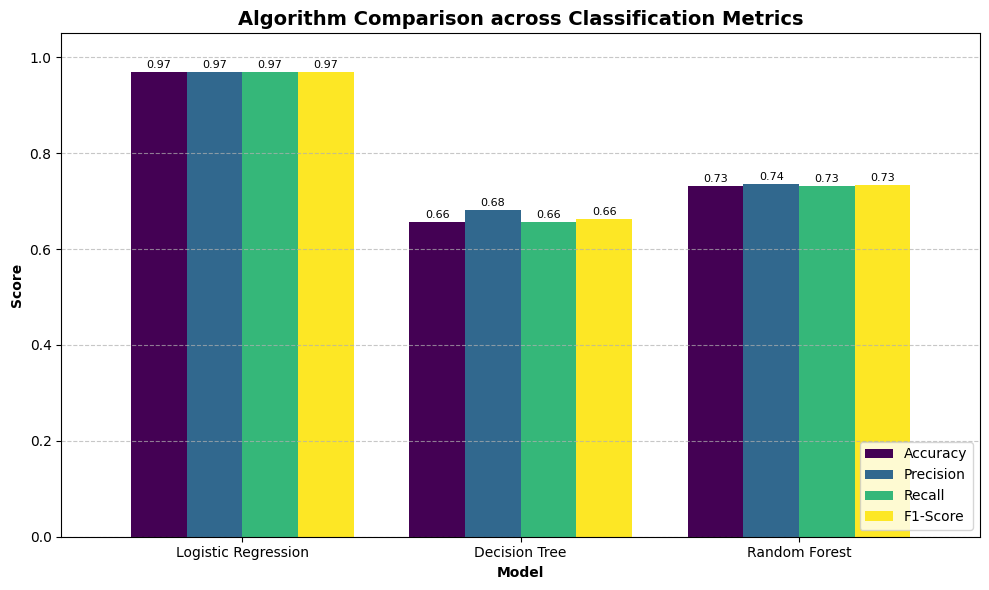

In [ ]:


# Create Comparison DataFrame
comparison_data = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [acc_lr, acc_dt, acc_rf],
    'Precision': [prec_lr, prec_dt, prec_rf],
    'Recall': [rec_lr, rec_dt, rec_rf],
    'F1-Score': [f1_lr, f1_dt, f1_rf]
}

df_comparison = pd.DataFrame(comparison_data)

# Print Summary Table
print("=" * 65)
print("MODEL PERFORMANCE COMPARISON SUMMARY")
print("=" * 65)
print(df_comparison.to_string(index=False))
print("=" * 65)

# Plot Comparative Bar Chart
df_plot = df_comparison.set_index('Model')
ax = df_plot.plot(kind='bar', figsize=(10, 6), colormap='viridis', width=0.8)

plt.title('Algorithm Comparison across Classification Metrics', fontsize=14, fontweight='bold')
plt.ylabel('Score', fontweight='bold')
plt.xlabel('Model', fontweight='bold')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')

# Annotate values above bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points',
                fontsize=8)

plt.tight_layout()
plt.show()

# Forecasting Macroeconomic Variables

# Forecasting Module — Predict Future Indicators, Then Risk

**Why this section exists:** the classifier above (`lr_model` / `dt_model` / `rf_model`) was trained to map the 7 macroeconomic indicators directly to a risk label, and the CMRI label was itself computed **from those same 7 indicators**. So when the original "User application" cell asked a person to manually type in `gdp_growth`, `inflation`, etc., the model wasn't really "predicting a country's future risk" — it was just re-deriving the CMRI formula it was trained on. It never learned to use `Country` and `Year` to reason about the future.

To make the app take only **Country + Target Year** as input, we need one extra model in front of the classifier: a **forecasting step** that estimates what the 7 indicators will plausibly be in that future year, for that country. Only then do we feed those forecasted indicators into the trained classifier to get a risk tier.

**Approach:** for each country, fit a simple linear trend (`indicator ~ Year`) on its historical (cleaned, pre-scaling) data — one trend line per indicator. To predict a future year, extrapolate that trend. If a country has too little history for a reliable trend (or the country wasn't in the training data at all), fall back to a global trend fitted across all countries. This is intentionally simple (linear extrapolation) — it is a reasonable baseline for a 1-2 year horizon; for longer horizons you may want to swap in an ARIMA/Prophet model per country/indicator instead.


# Linear Regression

for this we use the imputed unscaled dataset

In [ ]:


indicator_cols = [
    'current_account_bal',
    'domestic_credit',
    'exchange_rate_YoY',
    'gdp_growth',
    'inflation',
    'money_growth',
    'unemployment',
]

# 1. Load the CLEANED, IMPUTED, UN-SCALED indicator history (raw units,
#    saved right after the exchange-rate YoY step and before Robust Scaling).
raw_hist_path = os.path.join(output_folder, 'dataset_imputed_correctly_spark.csv')
pdf_hist = pd.read_csv(raw_hist_path)
pdf_hist = pdf_hist.dropna(subset=['Country', 'Year'])

# 2. Fit one linear trend model per country per indicator.
MIN_POINTS = 5  # need at least this many years of history to trust a country-level trend

country_models = {}       # {country: {indicator: LinearRegression}}
country_last_values = {}  # fallback snapshot: most recent known values per country

for country, grp in pdf_hist.groupby('Country'):
    grp = grp.sort_values('Year')
    country_models[country] = {}
    country_last_values[country] = grp.iloc[-1][indicator_cols].to_dict()
    for col in indicator_cols:
        sub = grp[['Year', col]].dropna()
        if len(sub) >= MIN_POINTS:
            model = LinearRegression()
            model.fit(sub[['Year']], sub[col])
            country_models[country][col] = model

# 3. Global fallback trend (used when a country/indicator has too little history,
#    or the country is not in the training data at all).
global_models = {}
for col in indicator_cols:
    sub = pdf_hist[['Year', col]].dropna()
    m = LinearRegression()
    m.fit(sub[['Year']], sub[col])
    global_models[col] = m

KNOWN_COUNTRIES = sorted(country_models.keys())


def forecast_indicators(country_name, target_year):
    """Forecast the 7 macro indicators for a country/year using per-country
    linear trends, falling back to the global trend when the country's own
    trend is missing or unreliable."""
    result = {}
    used_fallback = {}
    has_country = country_name in country_models
    for col in indicator_cols:
        model = country_models[country_name].get(col) if has_country else None
        used_fallback[col] = model is None
        if model is None:
            model = global_models[col]
        pred = model.predict(pd.DataFrame({'Year': [target_year]}))[0]
        result[col] = float(pred)
    return result, used_fallback


print(f"Forecasting module ready. {len(KNOWN_COUNTRIES)} countries have their own trend model.")
print("Example forecast:", forecast_indicators(KNOWN_COUNTRIES[0], 2026))


Forecasting module ready. 155 countries have their own trend model.
Example forecast: ({'current_account_bal': -8.180359174235491, 'domestic_credit': 35.52591526416586, 'exchange_rate_YoY': -3.9225387341035685, 'gdp_growth': 5.671589625258434, 'inflation': -41.371058734716826, 'money_growth': -10.392127309377429, 'unemployment': 11.237276750700289}, {'current_account_bal': False, 'domestic_credit': False, 'exchange_rate_YoY': False, 'gdp_growth': False, 'inflation': False, 'money_growth': False, 'unemployment': False})


# Evaluating the regression output of indicators

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize lists to store metrics for each indicator
indicator_performance = []

# Loop through each indicator column
for col in indicator_cols:
    all_actuals = []
    all_predictions = []

    # Iterate through each country to collect actuals and predictions
    for country, grp in pdf_hist.groupby('Country'):
        grp = grp.sort_values('Year')
        sub = grp[['Year', col]].dropna() # Actual historical data for this country and indicator

        if len(sub) > 0: # Ensure there is data to evaluate
            model_to_use = None
            # Determine which model was used for forecasting this country/indicator
            if country in country_models and col in country_models[country]:
                model_to_use = country_models[country][col]
            else:
                model_to_use = global_models[col]

            # Generate predictions using the fitted model on the historical years
            # Ensure 'Year' is reshaped correctly for sklearn models
            predictions = model_to_use.predict(sub[['Year']])

            all_actuals.extend(sub[col].values)
            all_predictions.extend(predictions)

    if len(all_actuals) > 0:
        # Calculate RMSE and R-squared for the current indicator
        rmse = np.sqrt(mean_squared_error(all_actuals, all_predictions))
        r2 = r2_score(all_actuals, all_predictions)

        indicator_performance.append({
            'Indicator': col,
            'RMSE': rmse,
            'R-squared': r2
        })

# Convert results to a Pandas DataFrame for better display
df_regression_metrics = pd.DataFrame(indicator_performance)

print("\n======================================================")
print("REGRESSION METRICS FOR MACROECONOMIC INDICATOR FORECASTS")
print("======================================================")
print(df_regression_metrics.to_string(index=False))
print("======================================================")



REGRESSION METRICS FOR MACROECONOMIC INDICATOR FORECASTS
          Indicator        RMSE  R-squared
current_account_bal    6.613168   0.794048
    domestic_credit   11.793018   0.925072
  exchange_rate_YoY  659.183018   0.107144
         gdp_growth    6.196623   0.174643
          inflation  355.717864   0.221500
       money_growth 1756.028663   0.045053
       unemployment    1.731366   0.915985


# Process the predicted data

In [ ]:



def predict_future_macro_risk(
    country_name,
    target_year,
    scaler_model=scaler_model,
    assembler=assembler,
    model=lr_model,
):
  """Predicts a country's future CMRI risk category (Low, Moderate, High)
  using ONLY the country name and a target year:
    1. Forecast the 7 macro indicators for that country/year (linear trend).
    2. Run the forecasted indicators through the SAME scaling + directional
       alignment used during training.
    3. Classify with the trained model (Logistic Regression by default).
  """
  # Step 1: forecast the raw indicators for the requested country/year
  forecasted, used_fallback = forecast_indicators(country_name, target_year)

  feature_cols = [
      "current_account_bal",
      "domestic_credit",
      "exchange_rate_YoY",
      "gdp_growth",
      "inflation",
      "money_growth",
      "unemployment",
  ]

  schema = StructType(
      [
          StructField("Country", StringType(), True),
          StructField("Year", IntegerType(), True),
      ]
      + [StructField(c, DoubleType(), True) for c in feature_cols]
  )

  input_data = [(
      country_name,
      int(target_year),
      *[float(forecasted[c]) for c in feature_cols],
  )]
  df_input = spark.createDataFrame(input_data, schema=schema)

  # Step 2: same preprocessing pipeline used during training
  df_input_vector = VectorAssembler(
      inputCols=feature_cols, outputCol="features_vector"
  ).transform(df_input)

  df_scaled = scaler_model.transform(df_input_vector)

  for i, col_name in enumerate(feature_cols):
    extract_elem = F.udf(lambda v, idx=i: float(v[idx]), "double")
    df_scaled = df_scaled.withColumn(
        col_name, extract_elem(F.col("scaled_features_vector"))
    )

  aligned_cols = []
  for c in feature_cols:
    if c in ["gdp_growth", "current_account_bal"]:
      aligned_cols.append((F.col(c) * -1.0).alias(c))
    else:
      aligned_cols.append(F.col(c))

  df_aligned = df_scaled.select(["Country", "Year"] + aligned_cols)
  df_ml_input = assembler.transform(df_aligned)

  # Step 3: classify
  predictions = model.transform(df_ml_input)
  pred_row = predictions.select("prediction", "probability").collect()[0]
  pred_label = int(pred_row["prediction"])

  label_map = {0: "Low Risk", 1: "Moderate Risk", 2: "High Risk"}
  risk_tier = label_map.get(pred_label, "Unknown")

  print("=" * 60)
  print(f"FUTURE MACROECONOMIC RISK PREDICTION: {country_name} ({target_year})")
  print("=" * 60)
  print("Forecasted indicators used (linear trend extrapolation):")
  for c in feature_cols:
    flag = " (global fallback, no/short country history)" if used_fallback[c] else ""
    print(f"  {c:<22}: {forecasted[c]:>8.2f}{flag}")
  print("-" * 60)
  print(f"Predicted Risk Tier: {risk_tier} (Numeric Class: {pred_label})")
  print(f"Class Probabilities: {pred_row['probability']}")
  print("=" * 60)

  return risk_tier, forecasted


In [ ]:
# @title Macroeconomic Risk Forecaster (Country + Year only)
import ipywidgets as widgets
from IPython.display import HTML, clear_output, display

country_input = widgets.Combobox(
    placeholder="Type a country name",
    options=KNOWN_COUNTRIES,
    description="Country:",
    style={"description_width": "initial"},
    ensure_option=False,
)

year_input = widgets.IntSlider(
    value=2026,
    min=2025,
    max=2035,
    step=1,
    description="Target Year:",
    style={"description_width": "initial"},
)

predict_button = widgets.Button(
    description="Forecast & Predict Risk",
    button_style="primary",
    icon="calculator",
    layout=widgets.Layout(width="280px", height="42px"),
)

output_area = widgets.Output()

theme = {
    "Low Risk": {"bg": "#e8f5e9", "border": "#2e7d32", "badge": "#4caf50"},
    "Moderate Risk": {"bg": "#fffde7", "border": "#fbc02d", "badge": "#fbc02d"},
    "High Risk": {"bg": "#ffebee", "border": "#c62828", "badge": "#e53935"},
}


def render_styled_prediction():
  country = country_input.value
  year = year_input.value

  risk_tier, forecasted = predict_future_macro_risk(country, year)
  t = theme.get(risk_tier, {"bg": "#f5f5f5", "border": "#9e9e9e", "badge": "#757575"})

  rows = "".join(
      f"<tr><td style='padding:4px 0;'><strong>{k}:</strong> {v:.2f}</td></tr>"
      for k, v in forecasted.items()
  )

  html_card = f"""
    <div style="
        background-color: {t['bg']};
        border-left: 8px solid {t['border']};
        border-radius: 8px;
        padding: 20px;
        margin-top: 15px;
        font-family: Arial, sans-serif;
        box-shadow: 0 4px 6px rgba(0,0,0,0.1);
    ">
        <div style="display: flex; justify-content: space-between; align-items: center;">
            <div>
                <h3 style="margin: 0; color: #333; font-size: 20px;">{country} ({year})</h3>
                <p style="margin: 5px 0 0 0; color: #666; font-size: 13px;">Forecasted Macroeconomic Risk Assessment</p>
            </div>
            <span style="
                background-color: {t['badge']};
                color: white;
                padding: 6px 16px;
                border-radius: 20px;
                font-weight: bold;
                font-size: 14px;
                text-transform: uppercase;
                letter-spacing: 0.5px;
            ">{risk_tier}</span>
        </div>
        <hr style="border: 0; border-top: 1px solid rgba(0,0,0,0.1); margin: 15px 0;">
        <table style="width: 100%; font-size: 13px; color: #444; border-collapse: collapse;">
            {rows}
        </table>
    </div>
    """
  display(HTML(html_card))


def on_button_clicked(b):
  with output_area:
    clear_output()
    try:
      render_styled_prediction()
    except Exception as e:
      display(HTML(f"<div style='color: red; padding: 10px;'><b>Error:</b> {e}</div>"))


predict_button.on_click(on_button_clicked)

ui_layout = widgets.VBox([
    widgets.HTML(
        "<h2 style='color: #00897b; font-family: Arial; font-weight:"
        " bold;'>Macroeconomic Risk Forecaster</h2>"
    ),
    widgets.HTML(
        "<p style='color: #888888; font-size: 13px;'>Pick a country and a"
        " future year — the app forecasts its macro indicators, then"
        " classifies the risk tier:</p>"
    ),
    widgets.HBox([country_input, year_input]),
    predict_button,
    output_area,
])

display(ui_layout)
